In [3]:
import pandas as pd

In [6]:
df = pd.read_csv('data/cleaned_online_retail.csv')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 407695 entries, 0 to 407694
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      407695 non-null  int64  
 1   StockCode    407695 non-null  str    
 2   Description  407695 non-null  str    
 3   Quantity     407695 non-null  int64  
 4   InvoiceDate  407695 non-null  str    
 5   Price        407695 non-null  float64
 6   Customer ID  407695 non-null  float64
 7   Country      407695 non-null  str    
 8   Revenue      407695 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 28.0 MB


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
analysis_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
analysis_date

Timestamp('2010-12-10 20:01:00')

In [10]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate" : lambda x : (analysis_date - x.max()).days, 
    "Invoice" : "nunique", 
    "Revenue": "sum" 
    })
rfm.columns = ["Recency", "Frequency", "Monetary"]

In [11]:
rfm

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93
...,...,...,...
18283.0,18,6,641.77
18284.0,67,1,461.68
18285.0,296,1,427.00


In [12]:
r_quintiles = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
f_quintiles = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
m_quintiles = pd.qcut(rfm["Monetary"], 5, labels = [1,2,3,4,5])
rfm["R"] = r_quintiles.astype(int)
rfm["F"] = f_quintiles.astype(int)
rfm["M"] = m_quintiles.astype(int)
rfm["RMF_score"] = rfm[["R", "F", "M"]].sum(axis=1)

In [13]:
rfm.head(5)

,Recency,Frequency,Monetary,R,F,M,RMF_score
Customer ID,,,,,,,
12346.0,165,11,372.86,2,5,2,9
12347.0,3,2,1323.32,5,2,4,11
12348.0,74,1,222.16,2,1,1,4
12349.0,43,3,2671.14,3,3,5,11
12351.0,11,1,300.93,5,1,2,8


In [14]:
def function(row): 
    if row["R"] >= 4 and row["F"] >= 4 and row["M"] >= 4:
        return "Baleine"
    elif row["R"] >= 4 and row["F"] < 3:
        return "Nouveau client"
    elif row["R"] >= 3 and row["F"] >= 4 and row["M"] >= 3:
        return "Client loyal"
    elif row["R"] >= 3 and row["F"] < 3  and row["M"] >= 3:
        return "Client prometteur"
    elif row["R"] < 2 and row["F"] >= 2 and row["M"] < 3:
        return "Client dormant"
    elif row["R"] < 3 and row["F"] >= 3 and row["M"] >= 4:
        return "Client a risque"
    elif  row["R"] < 3 and row["M"] >= 4 :
        return "Bon client perdu"
    else : 
        return "Autres clients"

rfm["type_client"] =  rfm.apply(function, axis=1)

In [24]:
rfm.head(10)

,Recency,Frequency,Monetary,R,F,M,RMF_score,type_client
Customer ID,,,,,,,,
12346.0,165,11,372.86,2,5,2,9,Autres clients
12347.0,3,2,1323.32,5,2,4,11,Nouveau client
12348.0,74,1,222.16,2,1,1,4,Autres clients
12349.0,43,3,2671.14,3,3,5,11,Autres clients
12351.0,11,1,300.93,5,1,2,8,Nouveau client
12352.0,11,2,343.80,5,2,2,9,Nouveau client
12353.0,44,1,317.76,3,1,2,6,Autres clients
12355.0,203,1,488.21,1,1,2,4,Autres clients
12356.0,16,3,3562.25,4,3,5,12,Autres clients


<Axes: xlabel='Monetary', ylabel='Count'>

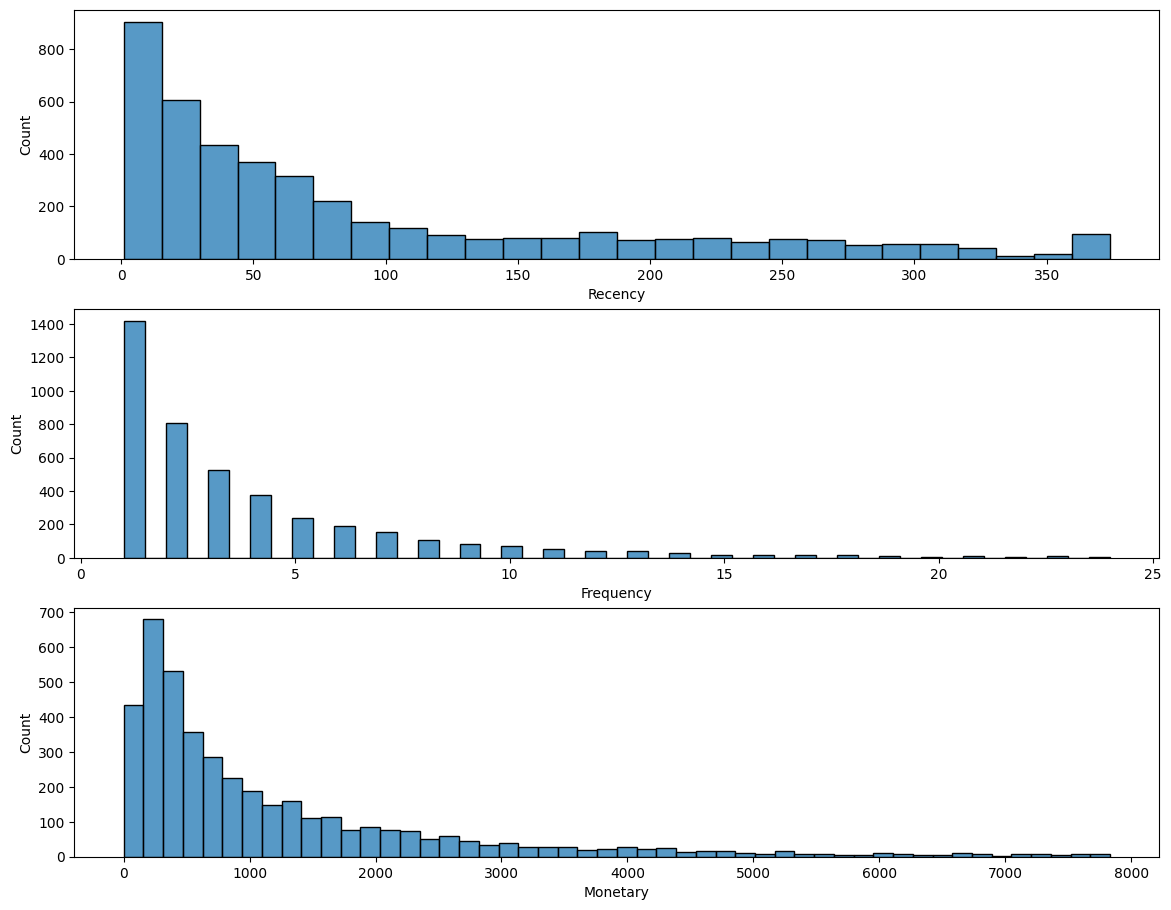

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#Histogrammes 
fig, axs = plt.subplots(3, 1, figsize=(14,11))
sns.histplot(data=rfm, x='Recency',ax=axs[0])
sns.histplot(data=rfm[rfm["Frequency"] <25], x='Frequency',  ax=axs[1])
sns.histplot(data=rfm[rfm["Monetary"] <8000] , x='Monetary',  ax=axs[2])

In [25]:
#Cartes de chaleurs 
rfm_depense_moy = pd.pivot_table(rfm, index = "R", columns ="F", values= "Monetary", aggfunc = 'mean')
rfm_depense_moy

F,1,2,3,4,5
R,,,,,
1,336.737198,429.347570,858.870845,1681.108833,4899.088333
2,419.480106,475.310270,834.540133,1716.342016,3951.824462
3,403.805393,481.790303,1060.357005,1689.367234,3644.603491
4,367.086782,609.429684,860.057530,1629.608627,4355.407392
5,386.199200,517.340845,830.873279,1526.898301,9252.757315


<Axes: xlabel='F', ylabel='R'>

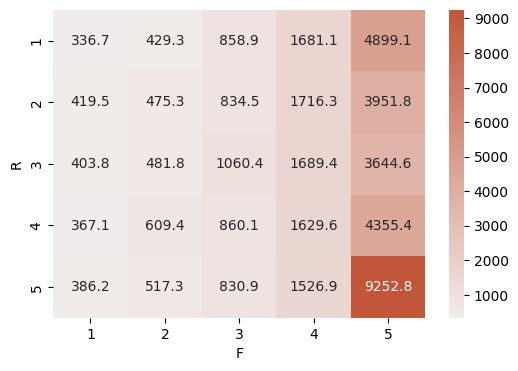

In [26]:
plt.figure(figsize=(6,4))
color = sns.diverging_palette(220, 20, as_cmap=True, )
sns.heatmap(rfm_depense_moy, annot=True, cmap=color,fmt=".1f", center=0)

<Axes: xlabel='type_client', ylabel='Count'>

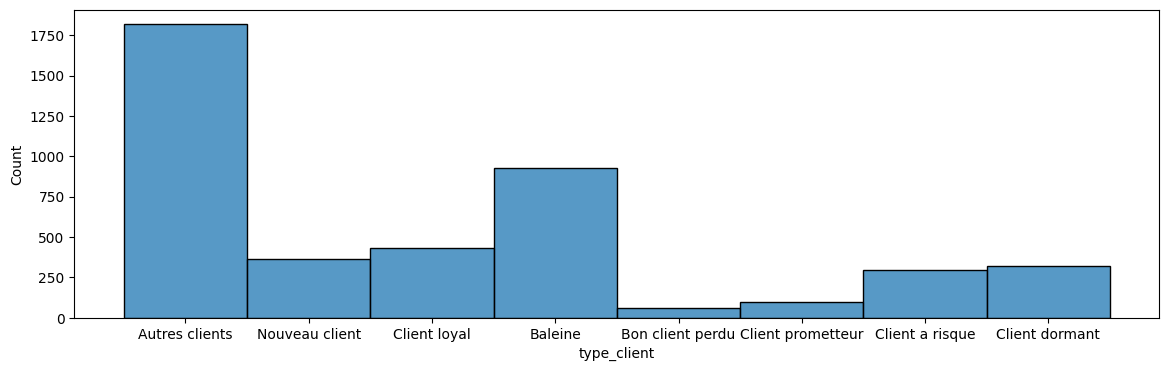

In [ ]:
#diagrammes barres 
plt.figure(figsize=(14, 4))
sns.histplot(data=rfm, x='type_client')

In [17]:
rfm["type_client"].value_counts()

type_client
Autres clients       1818
Baleine               926
Client loyal          432
Nouveau client        366
Client dormant        322
Client a risque       297
Client prometteur      96
Bon client perdu       57
Name: count, dtype: int64

Text(0.5, 1.0, 'Fréquence vs valeur monétaire selon récence')

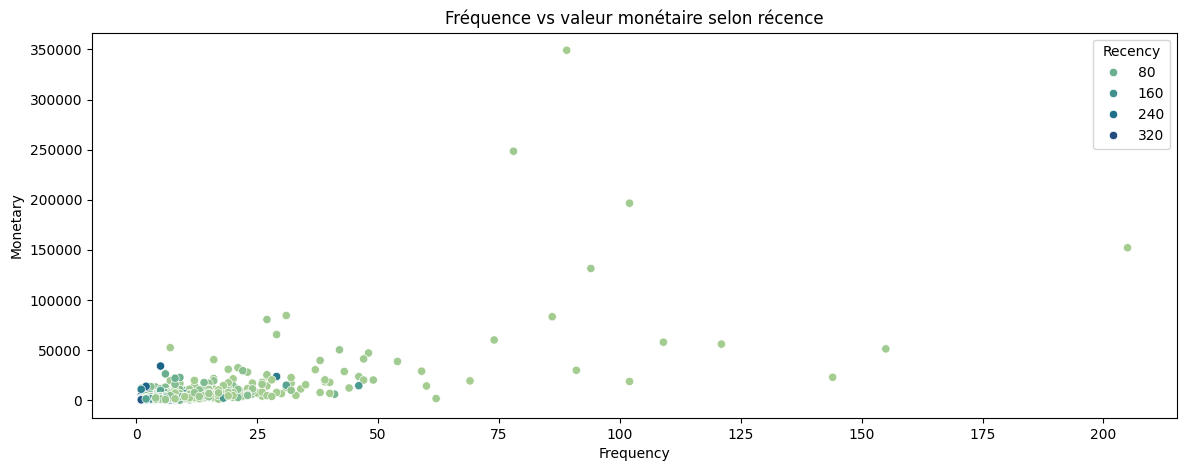

In [ ]:
#Nuage de points
plt.figure(figsize=(14,5))
col = sns.color_palette("crest", as_cmap=True)
sns.scatterplot(data = rfm, x = "Frequency", y = "Monetary", hue= "Recency", palette = col)
plt.title("Fréquence vs valeur monétaire selon récence")